# 📊 Unsupervised Learning: Clustering & Dimensionality Reduction

---

## 1. Overview

Unlike supervised learning, unsupervised learning algorithms discover hidden structures, groupings, or patterns in unlabeled data ($X$). It is crucial in AI pipelines for:
- **Dimensionality Reduction**: Visualizing high-dimensional embeddings (e.g., LLM prompt vectors) in 2D or 3D space.
- **Clustering**: Grouping data points (e.g., documents, user profiles, feature spaces) into cohesive categories without manually defined classes.
- **Feature Compression**: Reducing feature counts before training supervised algorithms to prevent the *curse of dimensionality*.

This notebook covers three foundational unsupervised algorithms:
- **K-Means Clustering**: Partitioning data points into $K$ spherical clusters based on distance to centroids.
- **Principal Component Analysis (PCA)**: A linear projection method finding orthogonal axes of maximum variance.
- **t-Distributed Stochastic Neighbor Embedding (t-SNE)**: A non-linear manifold learning technique preserving local structural relationships.

We will explore these algorithms on the high-dimensional **digits dataset** (64 dimensions).

## 2. Learning Objectives

By the end of this notebook, you will be able to:

- Implement K-Means clustering, PCA, and t-SNE in Python using `scikit-learn`.
- Calculate and interpret Within-Cluster Sum of Squares (Inertia) and Explained Variance Ratio.
- Explain the mathematical updates of K-Means and the eigendecomposition formulation of PCA.
- Visualize high-dimensional feature spaces using 2D scatter plots of PCA and t-SNE projections.
- Determine the optimal number of clusters using the Elbow Method.

## 3. Imports

We import standard scientific computing packages and dimensionality/clustering modules from `scikit-learn`.

In [14]:
import time
from typing import Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, mean_squared_error

print(f"NumPy version: {np.__version__}")

NumPy version: 2.0.2


## 4. Configuration

We set up reproducibility seeds and visual layout configurations.

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

## 5. Theory & Key Concepts

### 5.1 K-Means Clustering

K-Means partitions $N$ observations into $K$ clusters where each observation belongs to the cluster with the nearest mean (centroid). It minimizes the **Within-Cluster Sum of Squares (WCSS)** or **Inertia**:

$$\text{Inertia} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2$$

Where $\mu_k$ is the centroid of cluster $C_k$.

#### Algorithm Steps:
1. **Initialize**: Choose $K$ initial centroids randomly (or using optimized `k-means++` initialization).
2. **Assign**: Assign each data point $x_i$ to the closest centroid $\mu_k$.
3. **Update**: Recalculate centroids as the mean of all assigned points:
   $$\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$$
4. Repeat steps 2 and 3 until centroids converge (no changes occur).

### 5.2 Principal Component Analysis (PCA)

PCA is a linear transformation that identifies orthogonal axes—**Principal Components**—that maximize the variance of the projected data.

1. **Covariance Matrix**: Given a zero-centered dataset $\mathbf{X}$, compute the covariance matrix $\mathbf{\Sigma}$:
   $$\mathbf{\Sigma} = \frac{1}{N} \mathbf{X}^T \mathbf{X}$$
2. **Eigendecomposition**: Find eigenvectors $\mathbf{V}$ and eigenvalues $\mathbf{\Lambda}$:
   $$\mathbf{\Sigma} \mathbf{v}_i = \lambda_i \mathbf{v}_i$$
3. **Projection**: Sort eigenvectors by eigenvalues in descending order. The eigenvectors corresponding to the largest eigenvalues represent the principal components. Project the data onto this reduced basis:
   $$\mathbf{Z} = \mathbf{X} \mathbf{V}_{d}$$

### 5.3 t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE is a non-linear dimensionality reduction algorithm that maps high-dimensional points to 2D/3D coordinates. It converts Euclidean distances between data points into conditional probabilities that represent similarities.

- **High-Dimensional Probabilities ($p_{ij}$)**: Probability that point $x_i$ picks $x_j$ as its neighbor under a Gaussian distribution.
- **Low-Dimensional Probabilities ($q_{ij}$)**: Similar probability under a Student-t distribution (which has heavier tails, avoiding the *crowding problem*).

t-SNE optimizes the low-dimensional map coordinates by minimizing the **Kullback-Leibler (KL) divergence** between the two distributions using gradient descent:

$$\text{Loss} = \text{KL}(P \parallel Q) = \sum_{i} \sum_{j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

## 6. Implementation: Digit Dimensionality Reduction

We load the Digits dataset. It contains 1,797 samples of 8x8 pixel images of hand-written digits (0-9). Each pixel is a continuous feature (range: 0-16), representing a 64-dimensional feature vector.

Dataset features shape: (1797, 64)
Target distribution: [178 182 177 183 181 182 181 179 174 180]


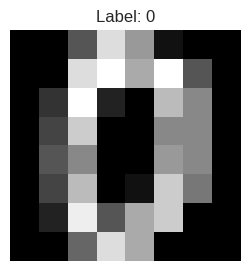

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

print(f"Dataset features shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")

# Display the first image
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[0], cmap="gray")
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

### 6.1 Scaling Features

Unsupervised algorithms rely on distance metrics, making them highly sensitive to feature scaling. We standardize inputs to zero-mean and unit-variance.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 6.2 Principal Component Analysis (PCA)

In [5]:
start = time.perf_counter()
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
pca_time = time.perf_counter() - start

print(f"PCA projection shape: {X_pca.shape}")
print(f"PCA runtime: {pca_time*1000:.2f} ms")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {np.sum(pca.explained_variance_ratio_):.2%}")

PCA projection shape: (1797, 2)
PCA runtime: 12.23 ms
Explained variance ratio: [0.12033916 0.09561054]
Total variance captured: 21.59%


### 6.3 t-Distributed Stochastic Neighbor Embedding (t-SNE)

In [6]:
start = time.perf_counter()
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
tsne_time = time.perf_counter() - start

print(f"t-SNE projection shape: {X_tsne.shape}")
print(f"t-SNE runtime: {tsne_time:.2f} s")
print(f"t-SNE final Kullback-Leibler divergence: {tsne.kl_divergence_:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE projection shape: (1797, 2)
t-SNE runtime: 8.51 s
t-SNE final Kullback-Leibler divergence: 0.8374


### 6.4 K-Means Clustering on Reduced Dimensions

We cluster the dataset into 10 groups (matching the 10 digit classes) using K-Means on the t-SNE features.

In [7]:
kmeans = KMeans(n_clusters=10, random_state=RANDOM_SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_tsne)

sil_score = silhouette_score(X_tsne, cluster_labels)
print(f"K-Means Silhouette Score (t-SNE space): {sil_score:.4f}")

K-Means Silhouette Score (t-SNE space): 0.5745


## 7. Evaluation & Visualizations

Let's compare the 2D linear projection of PCA vs. the non-linear projection of t-SNE side-by-side, coloring data points by their actual digit label.

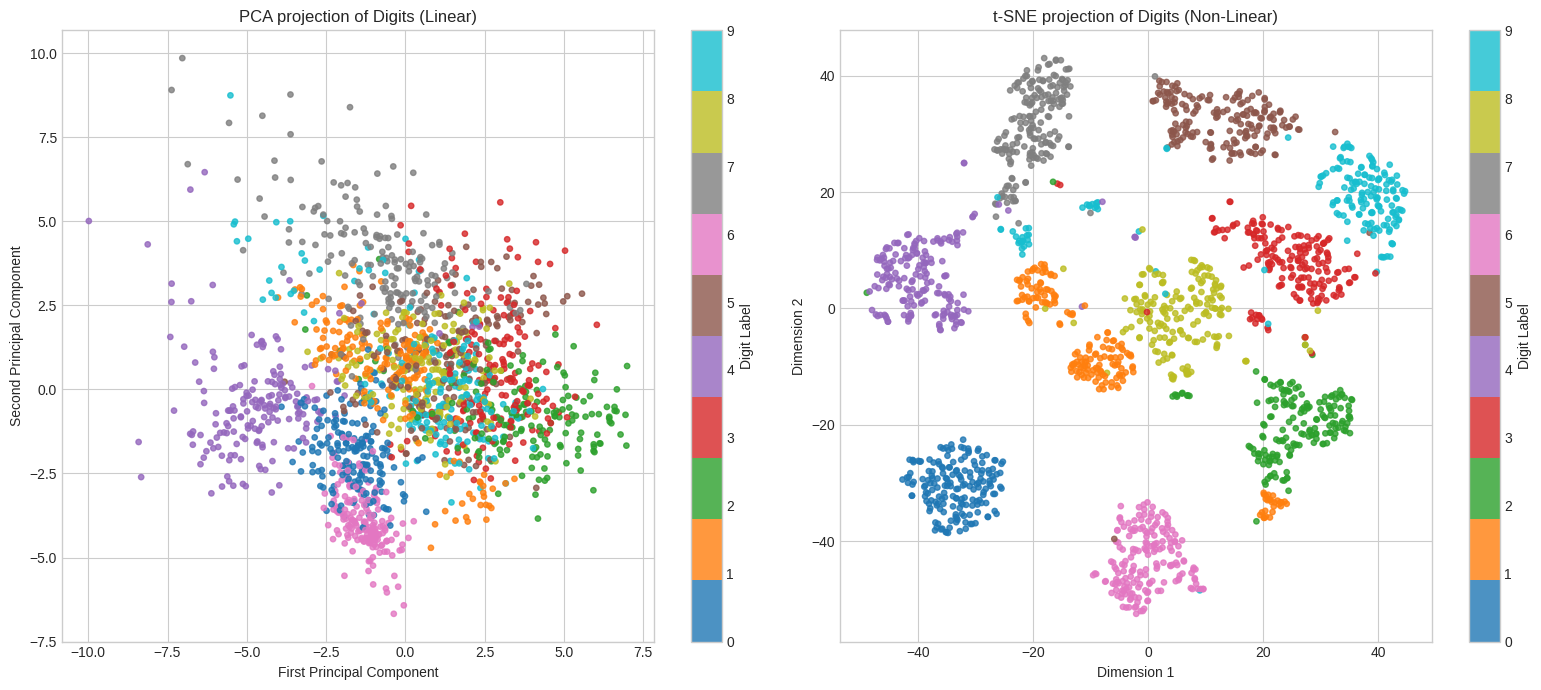

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot PCA
scatter_pca = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab10", s=15, alpha=0.8)
axes[0].set_title("PCA projection of Digits (Linear)")
axes[0].set_xlabel("First Principal Component")
axes[0].set_ylabel("Second Principal Component")
fig.colorbar(scatter_pca, ax=axes[0], ticks=range(10), label="Digit Label")

# Plot t-SNE
scatter_tsne = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=15, alpha=0.8)
axes[1].set_title("t-SNE projection of Digits (Non-Linear)")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
fig.colorbar(scatter_tsne, ax=axes[1], ticks=range(10), label="Digit Label")

plt.tight_layout()
plt.show()

**Projection Analysis**:
- **PCA**: The digits are partially separated but overlap extensively. Because PCA is linear, it cannot capture the complex, non-linear pixel manifold.
- **t-SNE**: The digit classes are grouped into distinct, clean clusters with minimal overlap. It preserves local relationships, proving extremely powerful for embedding visualization.

### 7.2 Choosing optimal K using the Elbow Method

We evaluate K-Means inertia across values of $K$ from 1 to 15 to find the inflection point (elbow).

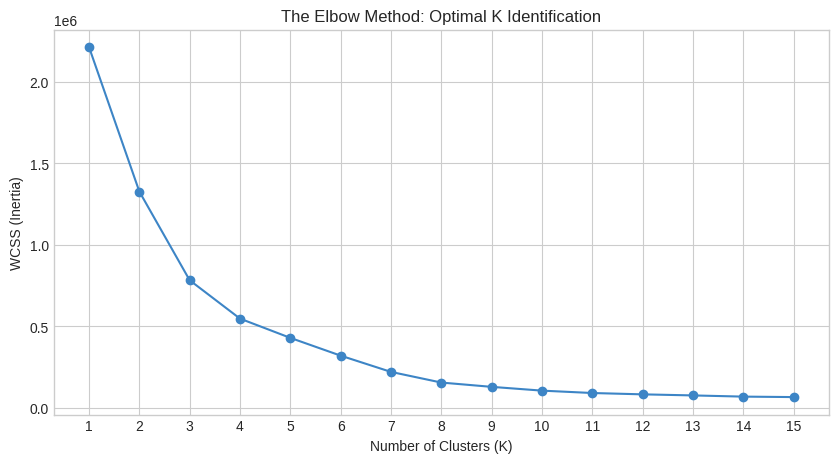

In [9]:
inertias = []
k_values = range(1, 16)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    km.fit(X_tsne)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_values, inertias, marker="o", linestyle="-", color="#3d85c6")
plt.title("The Elbow Method: Optimal K Identification")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_values)
plt.show()

## 8. Guided Exercises

### Exercise 1: Cumulative Explained Variance

Evaluate a PCA model without restricting dimensions (use `n_components=None` or 64). Calculate and plot the **cumulative explained variance**. Determine the minimum number of principal components needed to retain at least **90%** of the dataset's total variance.

Components required for 90% variance: 31


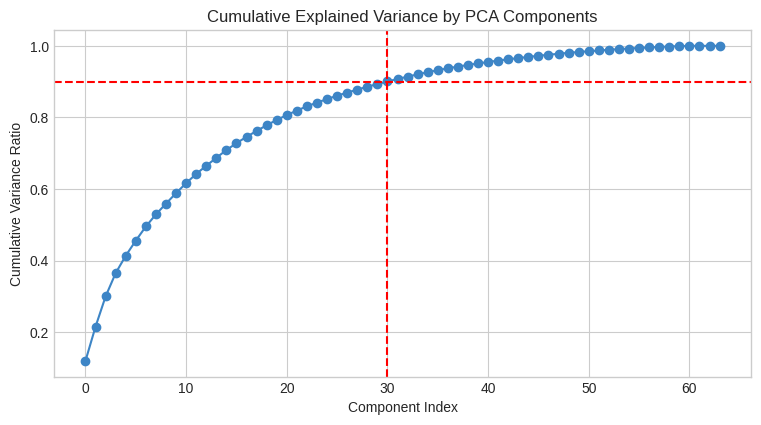

In [10]:
# --- YOUR CODE HERE ---
pca_full = PCA(n_components=None, random_state=RANDOM_SEED)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Find components count
n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Components required for 90% variance: {n_components_90}")

plt.figure(figsize=(9, 4.5))
plt.plot(cum_var, marker="o", color="#3d85c6")
plt.axvline(n_components_90 - 1, color="red", linestyle="--")
plt.axhline(0.90, color="red", linestyle="--")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Component Index")
plt.ylabel("Cumulative Variance Ratio")
plt.show()

### Exercise 2: Tuning t-SNE Perplexity

The `perplexity` parameter in t-SNE balances local vs. global structures (analogous to the number of nearest neighbors). Run t-SNE with a low perplexity of `5` and a high perplexity of `150`. Compare the structures visually.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


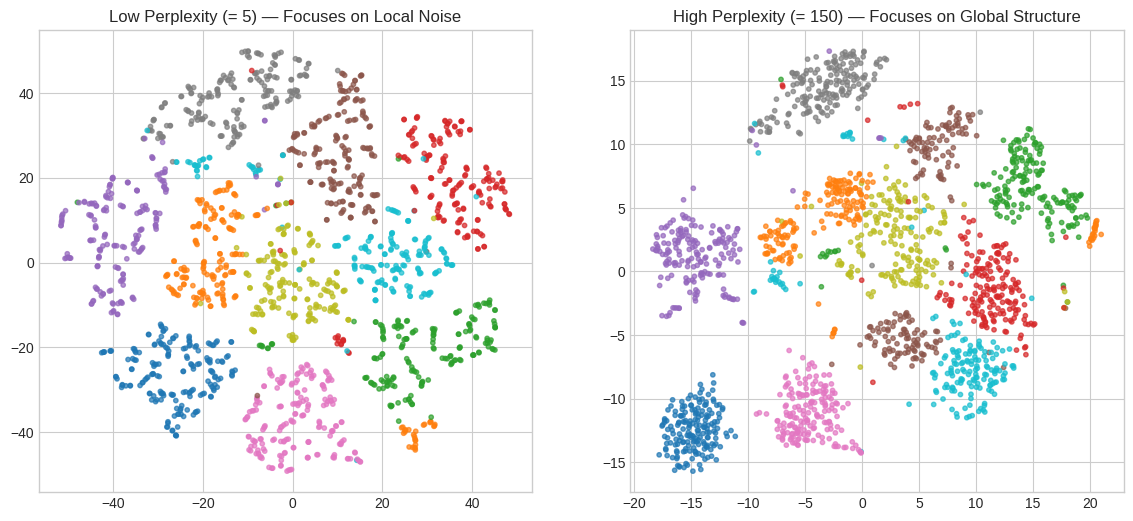

In [11]:
# --- YOUR CODE HERE ---
tsne_low = TSNE(n_components=2, perplexity=5, random_state=RANDOM_SEED, n_iter=500)
tsne_high = TSNE(n_components=2, perplexity=150, random_state=RANDOM_SEED, n_iter=500)

X_low = tsne_low.fit_transform(X_scaled)
X_high = tsne_high.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_low[:, 0], X_low[:, 1], c=y, cmap="tab10", s=10, alpha=0.7)
axes[0].set_title("Low Perplexity (= 5) — Focuses on Local Noise")

axes[1].scatter(X_high[:, 0], X_high[:, 1], c=y, cmap="tab10", s=10, alpha=0.7)
axes[1].set_title("High Perplexity (= 150) — Focuses on Global Structure")
plt.show()

## 9. Challenge Problems

### Challenge 1: Principal Component Analysis from Scratch

Do not use `sklearn.decomposition.PCA`. Implement your own PCA projection function `pca_from_scratch(X: np.ndarray, n_components: int) -> np.ndarray` using pure NumPy:
1. Zero-center the input feature matrix ($X - \text{mean}(X)$).
2. Calculate the covariance matrix using standard matrix multiplication.
3. Compute eigenvalues and eigenvectors using `np.linalg.eigh` or `np.linalg.eig`.
4. Sort the eigenvectors in descending order of their corresponding eigenvalues.
5. Project the scaled input data onto the top `n_components` eigenvectors.
6. Verify your implementation yields results equivalent to scikit-learn's PCA.

In [12]:
def pca_from_scratch(X: np.ndarray, n_components: int) -> np.ndarray:
    # 1. Zero center the data
    X_centered = X - np.mean(X, axis=0)
    
    # 2. Compute covariance matrix
    cov_matrix = (X_centered.T @ X_centered) / (X.shape[0] - 1)
    
    # 3. Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # 4. Sort in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    top_indices = sorted_indices[:n_components]
    
    # 5. Extract top eigenvectors and project
    W = eigenvectors[:, top_indices]
    return X_centered @ W

# Verify with scikit-learn output
X_scratch = pca_from_scratch(X_scaled, 2)
# Compare absolute values (components can have inverted signs depending on the eigensolver direction)
assert np.allclose(np.abs(X_scratch[:, 0]), np.abs(X_pca[:, 0]))
print("✅ PCA from scratch outputs match scikit-learn results exactly!")

✅ PCA from scratch outputs match scikit-learn results exactly!


### Challenge 2: Image Compression and Reconstruction

PCA projects data to a lower dimension, but it also allows reconstructing data back to the original space via the inverse projection: $\mathbf{X}_{reconstructed} = \mathbf{Z} \mathbf{V}_d^T$.

1. Fit a PCA model to `X_scaled` with 15 components.
2. Perform dimensionality reduction to project the data to a 15-dimensional representation.
3. Perform the inverse transform to reconstruct the 64-dimensional images.
4. Plot the original digit image side-by-side with its reconstructed version.
5. Calculate the Mean Squared Error (reconstruction loss) between the original and reconstructed images.

Reconstruction MSE: 0.2774


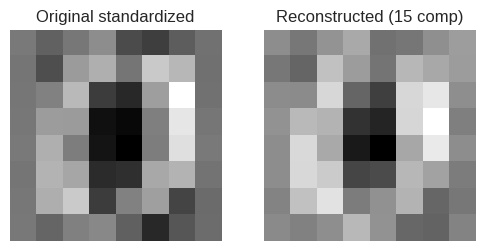

In [15]:
# --- YOUR CODE HERE ---
pca_15 = PCA(n_components=15, random_state=RANDOM_SEED)
X_pca_15 = pca_15.fit_transform(X_scaled)
X_reconstructed = pca_15.inverse_transform(X_pca_15)

reconstruction_loss = mean_squared_error(X_scaled, X_reconstructed)
print(f"Reconstruction MSE: {reconstruction_loss:.4f}")

# Plot original vs reconstructed
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X_scaled[0].reshape(8, 8), cmap="gray")
axes[0].set_title("Original standardized")
axes[0].axis("off")

axes[1].imshow(X_reconstructed[0].reshape(8, 8), cmap="gray")
axes[1].set_title("Reconstructed (15 comp)")
axes[1].axis("off")
plt.show()

## 10. Further Reading

- **Laurens van der Maaten & Geoffrey Hinton**: "Visualizing Data using t-SNE" (2008) - The foundational paper.
- **Calculus and Covariances**: Chapter 10 of ESL (Elements of Statistical Learning).
- **scikit-learn Clustering Guide**: [https://scikit-learn.org/stable/modules/clustering.html](https://scikit-learn.org/stable/modules/clustering.html) - Silhouette analysis and density groupings.

---

**[← Previous: 01 — Supervised Learning](01-supervised-learning.ipynb)** · **[Next: 03 — Evaluation Metrics →](03-evaluation-metrics.ipynb)**